Connecting to HF2LI...
Connected to dev376

Initializing HF2LI...
  Initializing signal inputs...
    Signal inputs initialized.
  Initializing signal outputs...
    Signal outputs initialized.
  Initializing oscillators...
    Oscillators initialized.
  Initializing demodulators...
    Demodulators initialized.
  Initializing PLLs...
    PLLs initialized.
  Initializing PID controllers...
    PID controllers initialized.
  Initializing scope...
    Scope initialized.
  Initializing auxiliary outputs...
    Auxiliary outputs initialized.

Initialization complete.

Configuring output 0...
  Output configured.
Configuring input 0...
  Input configured.
Configuring input 1...
  Input configured.
Configuring demodulator 0...
  Demodulator configured.
Configuring demodulator 1...
  Demodulator configured.

Experiment folder created
Data\2026-08-16_12-02-44

Settings saved.
Data\2026-08-16_12-02-44\settings.txt


Starting frequency sweep
1/200: 700.00 Hz
21/200: 750.25 Hz
41/200: 800.50 Hz
6

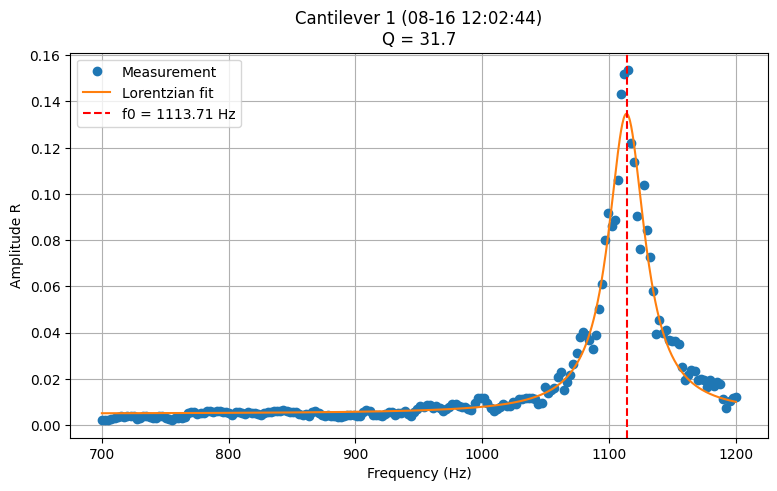

CHECKPOINT 6: PLOT 0 DONE

Starting plot demod 1


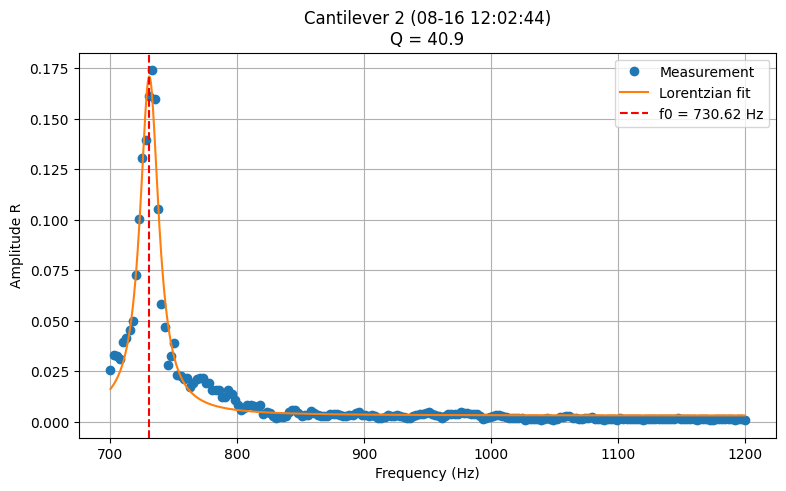

CHECKPOINT 7: PLOT 1 DONE

Top intersection(s) by amplitude:
Frequency = 845.430186 Hz, Amplitude = 5.882688e-03
Frequency = 845.910774 Hz, Amplitude = 5.808721e-03
Frequency = 819.835110 Hz, Amplitude = 5.275954e-03


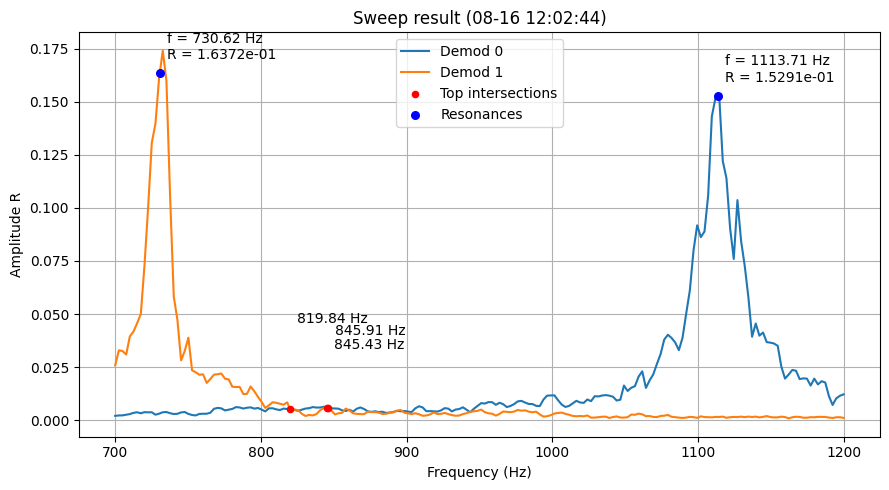

CHECKPOINT 8: SWEEP PLOT DONE


In [1]:
import os # enable the file system operation //12AUG YZ
from datetime import datetime # added for enabling timestamp in the plot title //07AUG YZ //12AUG YZ

from instrument.hf2li import HF2LI
from instrument import config 

from measurements.sweeper import FrequencySweeper
from measurements.experiment import ExperimentRunner

from utils.dataio import save_sweep_to_folder

from analysis.resonance import fit_resonance


# this cell creates a folder which has the name  of the current date and time. 
# it contains two files: settings.txt and sweep.npz. the settings.txt file contains the settings of the lock-in amplifier, 
# and the sweep.npz file contains the data of the frequency sweep. //06AUG YZ
# Create HF2LI driver, no communication to or control over the instrument yet
lockin = HF2LI(
    device_id=config.DEVICE_ID,
    host=config.SERVER_HOST,
    hf2=config.HF2
)

# connect to instrument.
lockin.connect()

# Initialize the instrument to a known safe state, and every experiment should start from this state.
# - outputs disabled
# - demodulators disabled
# - oscillators reset
# - feedback systems disabled
lockin.initialize()

# Configure experiment

# Signal output
lockin.configure_output(
    channel=config.OUTPUT_CHANNEL,
    amplitude=config.AMPLITUDE,
    offset=config.OFFSET
)

# Signal inputs
lockin.configure_input(
    channel=0,
    input_range=config.INPUT_RANGE_1
)

lockin.configure_input(
    channel=1,
    input_range=config.INPUT_RANGE_2
)

# Demodulators
lockin.configure_demod(
    demod=config.DEMOD_1,
    adc=config.ADC_1,
    oscillator=config.OSCILLATOR_1,
    rate=config.DEMOD_RATE_1
)


lockin.configure_demod(
    demod=config.DEMOD_2,
    adc=config.ADC_2,
    oscillator=config.OSCILLATOR_2,
    rate=config.DEMOD_RATE_2
)

# =========================================================
# Create experiment folder#
# Everything related to this experiment will be saved here:#
# settings.txt
# sweep.npz
# fit results
# interactive measurements#
# =========================================================

# =========================================================
# Experiment metadata#
# General information about this experiment.
# The angle is added for later complex-plane analysis.
# =========================================================

experiment_angle = float(
    input(
        "Experimental angle (deg): "
    )
)
# ask for input the experimental angle in degrees for sweeping  // 13AUG YZ

metadata = {

    "device": config.DEVICE_ID,

    "experiment":
        "Two cantilever resonance measurement",

    "experiment_angle":
        experiment_angle

}


experiment = ExperimentRunner(
    recorder=None,
    settings=config.settings,
    metadata=metadata
)

# =========================================================
# Frequency sweep
# The oscillator frequency is swept.
# Both demodulators are recorded.
# =========================================================

timestamp = datetime.now().strftime("%m-%d %H:%M:%S") # implemenet the timestamp in the plot title //07AUG YZ // move timestamp to the beginning of sweep 12AUG YZ

sweeper = FrequencySweeper(
    lockin
)

data = sweeper.sweep(
    start_frequency=config.F_START,
    stop_frequency=config.F_STOP,
    points=config.POINTS,
    demods=(0,1),
    live_plot=False # change to false to disable live plotting //10AUG YZ
)

lockin.disable_excitation()

print()
print("Sweep finished.")
print(data.keys())
print()

# =========================================================
# Save sweep
# The raw sweep is stored inside the experiment folder.
# =========================================================

sweep_file = save_sweep_to_folder(
    data,
    experiment.run_folder
)

print("Experiment folder:")
print(experiment.run_folder)

print("sweepfile")
print(sweep_file)

# the sweep data is saved in the experiment folder, the sweep.npz file contains the data of the frequency sweep. //07AUG YZ

# move resonance resulting and plotting here, begins //11AUG YZ
## =========================================================
# Load saved sweep data
#
# We analyze the saved raw measurement.
# The instrument data itself is not modified.
# =========================================================

# this cell's execution would ask for three times of input:
    # 1st describes the experiment, 2nd is the folder name of the experiment, 3rd is the confirmation of start //07AUG YZ
#in the folder of the experiment, settings andsweep.npz are generated when the first cell is excuted. //07AUG YZ

# the cell picks up the CH1 resonance frequency to continue the experiment as the first step. //07AUG YZ

import numpy as np

print()
print("CHECKPOINT 1: Loading sweep")
loaded = np.load(
    sweep_file,
    allow_pickle=True
)

print("Loaded file:")
print(sweep_file)

print()
print("Available channels:")
print(loaded.files)


# =========================================================
# Convert numpy archive into dictionary
# =========================================================

data_loaded = {
    key: loaded[key]
    for key in loaded.files
}

print()

print("CHECKPOINT 2: Sweep converted to dictionary")

# =========================================================
# Extract frequency and amplitudes
#
# Demod 0 -> first cantilever
# Demod 1 -> second cantilever
# =========================================================

from analysis.parser import (
    get_frequency,
    get_channel
)

frequency = get_frequency(data_loaded)


amplitude_0 = get_channel(
    data_loaded,
    demod=0,
    quantity="r"
)

amplitude_1 = get_channel(
    data_loaded,
    demod=1,
    quantity="r"
)

print()
print("CHECKPOINT 3: Channels extracted")
print(
    "Frequency points:",
    len(frequency)
)
print(
    "Demod 0:",
    len(amplitude_0)
)
print(
    "Demod 1:",
    len(amplitude_1)
)


# Resonance fitting

from analysis.resonance import fit_resonance


print()
# cantilever 1/channel 1 resonance fit
print("Starting fit demod 0")
fit_0 = fit_resonance(
    frequency,
    amplitude_0
)# resonance frequency and amplitude
print()
print("Demod 0")
print(fit_0)
print("CHECKPOINT 4: FIT 0 DONE")

# fit_0 = fit_resonance get a output with structure as: //13AUG YZ
    # fit_0["f0"]          # resonance frequency
    # fit_0["gamma"]       # linewidth
    # fit_0["Q"]           # quality factor
    # fit_0["parameters"]  # fitting parameters
    # fit_0["covariance"]  # fitting uncertainty information
# there is no amplitude included in it //13AUG YZ


print()
# cantilever 2/channel 2 resonance fit
print("Starting fit demod 1")
fit_1 = fit_resonance(
    frequency,
    amplitude_1
)# resonance frequency and amplitude
print()
print("Demod 1")
print(fit_1)
print("CHECKPOINT 5: FIT 1 DONE")


# Plot resonance fits

from analysis.plotting import plot_resonance_fit
from analysis.plotting import plot_sweep

print()
print()

print(experiment.run_folder)

print("plot resonance")

plot_resonance_fit( # save the plot of the resonance has been added//15AUG YZ
    frequency,
    amplitude_0,
    fit_0,
    # title="Cantilever 1"
    save_path = os.path.join(
        experiment.run_folder,
        "resonance_cantilever_1.png"
    ),
    title=f"Cantilever 1 ({timestamp})"
)
print("CHECKPOINT 6: PLOT 0 DONE")

print()
print("Starting plot demod 1")
plot_resonance_fit(
    frequency,
    amplitude_1,
    fit_1,
    # title="Cantilever 2"
    save_path = os.path.join(
        experiment.run_folder,
        "resonance_cantilever_2.png"
    ),
    title=f"Cantilever 2 ({timestamp})"

)
print("CHECKPOINT 7: PLOT 1 DONE")

plot_sweep(
    frequency,
    amplitude_0,
    amplitude_1,
    fit_0,
    fit_1,
    timestamp=timestamp,
    save_path=os.path.join(
        experiment.run_folder,
        "sweep.png"
    )
)

# move resonance resulting and plotting here, ends //11AUG YZ

# plot the sweep result, begins //12AUG YZ

# move plotting of sweep to plotting.py begins //15AUG YZ
# move plotting of sweep to plotting.py ends //15AUG YZ

print("CHECKPOINT 8: SWEEP PLOT DONE")

# plot the sweep result, ends //12AUG YZ

In [2]:
# move to 1st cell to show resonance plotting, begins //11AUG YZ
# move to 1st cell to show resonance plotting, ends//11AUG YZ
# =========================================================
# Select resonance frequency
#
# Currently using cantilever 1.
# =========================================================


# f0 = fit_0["f0"] commented to run a specified test with two cantilevers under 900 Hz //12AUG
# f0 = 915
# set the CH1 resonance frequency as the oscillator frequency for the next stps //07AUG YZ

import os

while True: # initial input for the experiment frequency //15AUG YZ

    f0_input = input(
        "Experiment frequency, q = quit: "
    ).strip()

    if f0_input.lower() == "q":
        print("Experiment finished.")
        raise SystemExit

    try:
        f0 = int(f0_input) # only accept an integer for input//15AUG YZ
        break

    except ValueError:
        print("Invalid input. Please enter an integer or q.")


frequency_file = os.path.join( #
    experiment.run_folder,
    f"{f0}_Hz.txt" # entered frequency will be the filename //15AUG YZ
)

while True:

    distance_input = input(
        "Distance, q = quit: "
    ).strip()

    if distance_input.lower() == "q":
        print("Experiment finished.")
        raise SystemExit

    try:
        distance = float(distance_input)
        break

    except ValueError:
        print("Invalid input. Please enter a number or q.")

with open(frequency_file, "w") as file: # write the distance value into file created //15AUG YZ
    file.write(f"{distance}\n")


# =========================================================
# Save fitting results
# =========================================================


from utils.dataio import save_fit

print()

print("Saving fit results")

save_fit(
    fit_0,
    experiment.run_folder,
    filename="fit_demod0.json"
)

print("CHECKPOINT 8: FIT 0 SAVED")

save_fit(
    fit_1,
    experiment.run_folder,
    filename="fit_demod1.json"
)

print("CHECKPOINT 9: FIT 1 SAVED")

# =========================================================
# Set oscillator frequency
# =========================================================


print()
print("Setting HF2LI frequency")


lockin.set_frequency(f0)
lockin.disable_excitation()

print("CHECKPOINT 10: FREQUENCY SET")

# =========================================================
# Prepare interactive measurement
# =========================================================

from measurements.recorder import HF2LIRecorder

print()

print("Creating recorder")

recorder = HF2LIRecorder(
    lockin,
    demods=(0,1)
)

print("CHECKPOINT 11: RECORDER CREATED")

# Attach recorder to existing experiment

experiment.recorder = recorder
print("CHECKPOINT 12: RECORDER ATTACHED")

# =========================================================
# Start interactive experiment
# =========================================================


print()
print("STARTING INTERACTIVE EXPERIMENT")

experiment.run(
    duration=2.0
)


Saving fit results

Fit saved:
Data\2026-08-16_12-02-44\fit_demod0.json
CHECKPOINT 8: FIT 0 SAVED

Fit saved:
Data\2026-08-16_12-02-44\fit_demod1.json
CHECKPOINT 9: FIT 1 SAVED

Setting HF2LI frequency
Excitation disabled
CHECKPOINT 10: FREQUENCY SET

Creating recorder
CHECKPOINT 11: RECORDER CREATED
CHECKPOINT 12: RECORDER ATTACHED

STARTING INTERACTIVE EXPERIMENT
Excitation disabled

--------------------------------
Measurement 1

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1804
Demod 1 points: 1787
Synchronizing to 1787 points
Points recorded: 1787
Excitation disabled
Excitation disabled
Recording finished.
DEBUG experiment_angle = 0.0
Saved: Data\2026-08-16_12-02-44\001_angle_0.npy
Excitation disabled

--------------------------------
Measurement 2

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1800
Demo

Reading:
Data\2026-08-15_18-50-35

Fit demod 0:
{'f0': 1113.5048584331776, 'gamma': 16.716192855160724, 'Q': 33.306174081660274, 'parameters': [1113.5048584331776, 16.716192855160724, 0.12691193196540587, 0.005052460076409764], 'covariance': [[0.07729511734886874, -0.00017347556983902447, -6.641287255045256e-07, 8.339692328264011e-07], [-0.0001734755698390245, 0.18632249848950583, -0.0005723699692533682, -7.107311214175636e-05], [-6.641287255045256e-07, -0.0005723699692533681, 4.477949795802088e-06, -4.522616810364052e-08], [8.339692328264013e-07, -7.107311214175636e-05, -4.5226168103640455e-08, 1.6902656477955036e-07]]}

Fit demod 1:
{'f0': 731.791630243193, 'gamma': 11.40278614224182, 'Q': 32.088281807384696, 'parameters': [731.791630243193, 11.40278614224182, 0.14241760022658592, 0.0030317933480867422], 'covariance': [[0.026015930210532542, -0.00038721782968960145, 2.3713022661863104e-06, -6.598968963707818e-07], [-0.00038721782968960134, 0.05991930225949991, -0.0003290715297358178,

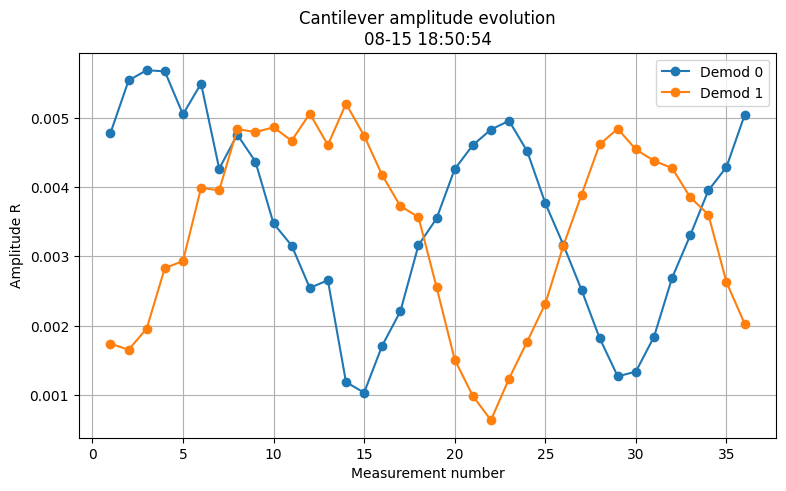

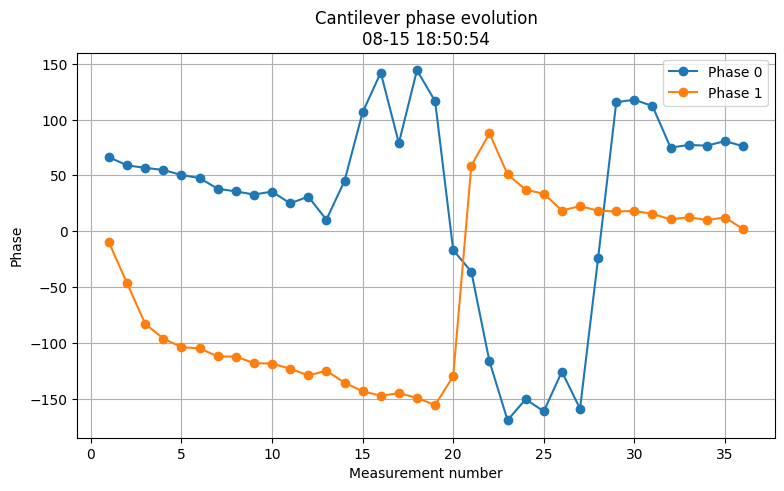

In [ ]:
# =========================================================
# Test reading saved experiment data#
# No HF2LI connection is required.
# We only read files from the experiment folder.
# =========================================================

import os
import numpy as np
import json
from datetime import datetime # added for enabling timestamp in the plot title //10AUG YZ

# =========================================================
# Select experiment folder
# =========================================================

experiment_folder = (
    r"Data\2026-08-15_18-50-35"
    #the experiment folder, change this folder name to the one you want to read. in most cases, it is the latest folder in the Data directory. 
    #nothing changed here, just added a comment for clarity. //06AUG YZ
)

print("Reading:")

print(experiment_folder)

# move to the sweep cell, begins //12AUG YZ
# plotting function implementation //12AUG YZ
# move to the sweep cell, ends //12AUG YZ

# =========================================================
# Read saved fits
# =========================================================


fit0_file = os.path.join(
    experiment_folder,
    "fit_demod0.json"
)

fit1_file = os.path.join(
    experiment_folder,
    "fit_demod1.json"
)

with open(fit0_file,"r") as f:

    fit0 = json.load(f)

with open(fit1_file,"r") as f:

    fit1 = json.load(f)

print()
print("Fit demod 0:")
print(fit0)


print()
print("Fit demod 1:")
print(fit1)


# move summary of measurements here, begins //13AUG YZ
from analysis.measurement_reader import (
    load_measurements,
    summarize_measurements
)
from utils.dataio import save_summary

#folder = r"Data\2026-08-13_13-31-29" commented since summary of measurements is moved into same cell //13AUG YZ
#the experiment folder, change this folder name to the one you want to read. in most cases, it is the latest folder in the Data directory. 
#nothing changed here, just added a comment for clarity. //06AUG YZ

measurements = load_measurements(experiment_folder) # experiement_folder is changed from folder since summary of measurements is moved into same cell //13AUG YZ

summary = summarize_measurements(measurements)

save_summary(
    summary,
    experiment_folder # experiement_folder is changed from folder since summary of measurements is moved into same cell //13AUG YZ
)
print(summary)

# move summary of measurements here, ends //13AUG YZ

# move plot of summary of amplitude and phase here, begins//13AUG YZ
from analysis.plotting import (
    plot_measurement_summary,
    plot_phase_summary
)

plot_measurement_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "amplitude_summary.png"
    )
)
# save plot of amplitude //15AUG YZ

plot_phase_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "phase_summary.png"
    )
)
# move plot of summary of amplitude and phase here, ends //13AUG YZ
# save the plot of phase //15AUG YZ

Found 36 measurement files
001_angle_0.npy: angle=0.0° | z0=0.0019+0.0043j | z1=0.0017-0.0003j | zr=0.6401+2.6635j | zd=0.0002+0.0046j | zm=2.7439
002_angle_10.npy: angle=10.0° | z0=0.0028+0.0047j | z1=0.0011-0.0012j | zr=-0.8968+3.2727j | zd=0.0017+0.0059j | zm=3.3513
003_angle_20.npy: angle=20.0° | z0=0.0031+0.0047j | z1=0.0002-0.0019j | zr=-2.2151+1.8573j | zd=0.0028+0.0066j | zm=2.9013
004_angle_30.npy: angle=30.0° | z0=0.0032+0.0046j | z1=-0.0003-0.0028j | zr=-1.7431+0.9739j | zd=0.0035+0.0074j | zm=2.0013
005_angle_40.npy: angle=40.0° | z0=0.0032+0.0038j | z1=-0.0007-0.0028j | zr=-1.5415+0.7397j | zd=0.0039+0.0067j | zm=1.7225
006_angle_50.npy: angle=50.0° | z0=0.0037+0.0040j | z1=-0.0010-0.0038j | zr=-1.2160+0.6383j | zd=0.0047+0.0079j | zm=1.3771
007_angle_60.npy: angle=60.0° | z0=0.0033+0.0026j | z1=-0.0015-0.0036j | zr=-0.9327+0.5306j | zd=0.0048+0.0062j | zm=1.0792
008_angle_70.npy: angle=70.0° | z0=0.0039+0.0028j | z1=-0.0018-0.0045j | zr=-0.8319+0.5241j | zd=0.0057+0.0072j


71 67 77 89
=-=-=-=-=-=
Calibration saved: Data\2026-08-15_18-50-35\calibration.npy


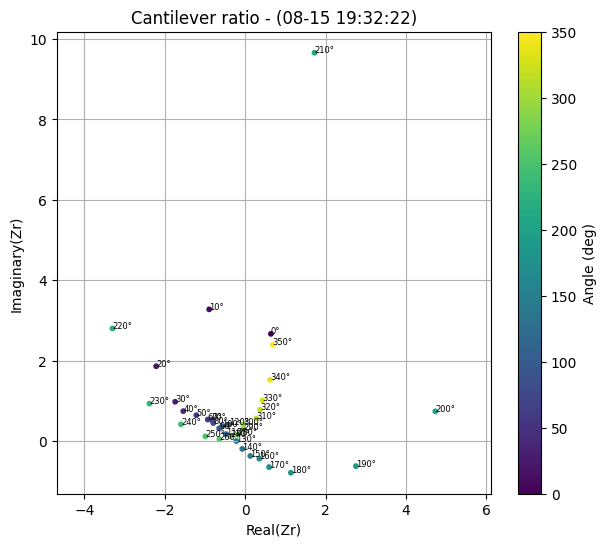

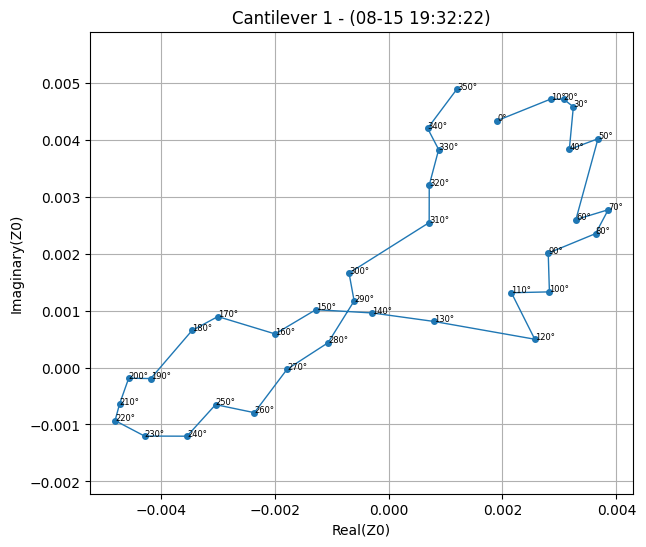

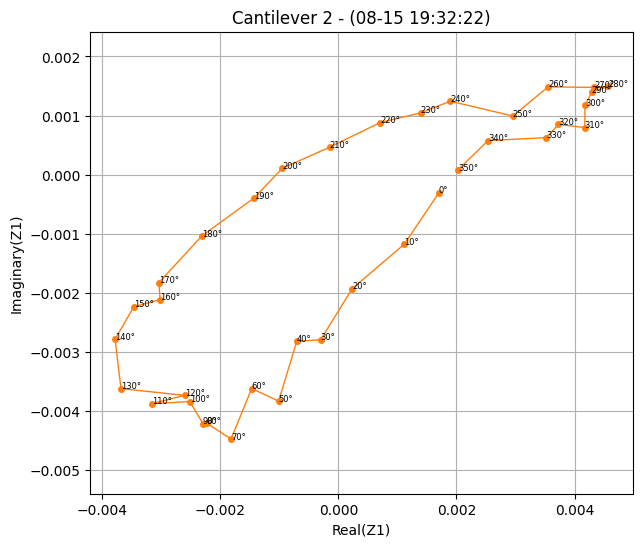

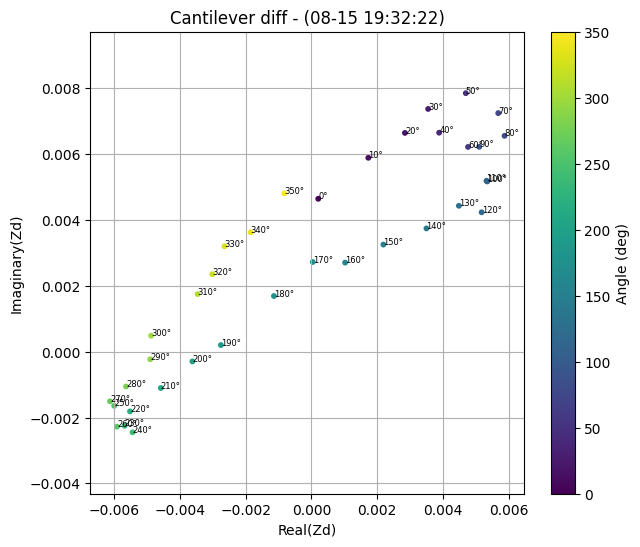

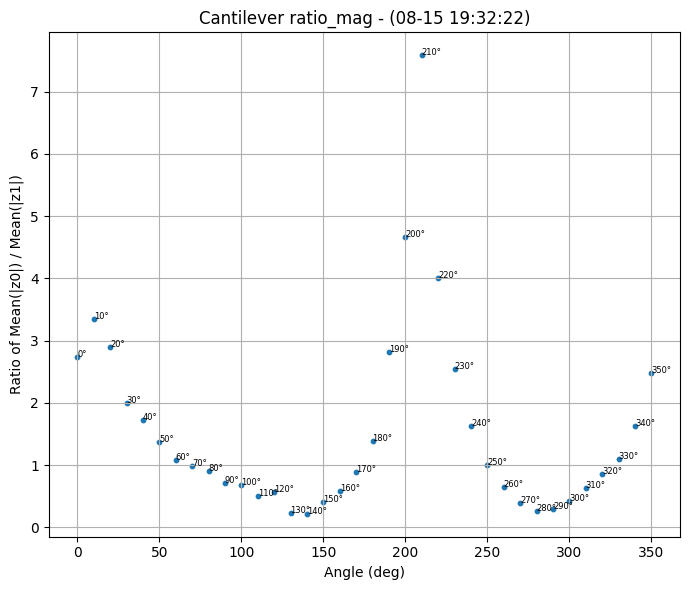

In [ ]:
from analysis.calibration import build_calibration
from analysis.calibration import save_calibration
from analysis.calibration import load_calibration

from analysis.calibration_plot import plot_calibration
from analysis.calibration_plot import plot_calibration_cantilevers #11AUG YZ
from analysis.calibration_plot import plot_calibration_diff #12AUG YZ
from analysis.calibration_plot import plot_calibration_rmmag

import os

experiment_folder = r"Data\2026-08-15_18-50-35" # input the experiement folder //13AUG YZ

# build the calibration file //13AUG YZ
calibration = build_calibration(
   experiment_folder # original = r"Data\2026-08-13_18-14-05", changed to use identified folder
)

print(calibration.keys())
print(calibration["angles"])
print(calibration["ratio_points"])

# the calibration file was under the data folder, it is changed to the same folder as the experiment folder. // 07AUG YZ
save_calibration(
    calibration,
    #experiment_folder + r"Data\2026-08-13_18-14-05\calibration.npy"
    experiment_folder + r"\calibration.npy"
)

# load the calibration from the file and plot it. the calibration file is generated by the previous cell. //06AUG YZ
calibration = load_calibration(
    experiment_folder + r"\calibration.npy"
)

plot_calibration(
    calibration,
    save_path=os.path.join(
            experiment_folder,
            "ratio_mean_cplx.png")
    )#plot cantilever 1 / cantilever 2

plot_calibration_cantilevers(
    calibration,
    save_path_CL1 = os.path.join(
            experiment_folder,
            "mean_CL1.png"),
    save_path_CL2 = os.path.join(
            experiment_folder,
            "mean_CL2.png")
)#plot cantilever characteristics from CH1 CH2 //11AUG YZ

plot_calibration_diff(
    calibration,
    save_path=os.path.join(
        experiment_folder,
        "diff_mean.png") 
) #plot cantilever 1 - cantilever 2

plot_calibration_rmmag(
    calibration,
    save_path=os.path.join(
        experiment_folder,
        "ratio_mean_mag.png") #plot Mean(|z0|) / Mean(|z1|) 
)

In [5]:
# HERE WE RUN unknown_measurement which we want to compare with the calibration!!!

# this cell will generate a new file under the folder of the experiment, the file name is defined by the user input. //07AUG YZ
# the duration of experiment is written in the code with a unit of seconds, and the value is a float. //07AUG YZ


experiment.run(
    duration=2.0
)

Excitation disabled

--------------------------------
Measurement 1


ValueError: could not convert string to float: 'about225'

In [3]:
from analysis.calibration import estimate_angle
from analysis.calibration import estimate_angle_interpolated
from utils.dataio import load_measurement_pathinput
from utils.dataio import load_measurement

# commented to call new load file implementation //14AUG YZ
# unknown_measurement = np.load(
#     r"Data\2026-08-10_19-58-27\001_read240.npy",
#     allow_pickle=True
# ).item()

unknown_measurement = load_measurement_pathinput()

if unknown_measurement is None:
    exit()


result = estimate_angle(
    unknown_measurement,
    calibration
)

print(result)



result = estimate_angle_interpolated(
    unknown_measurement,
    calibration
)

print(result)

# original code was tring to plot the complex ratio of the unknown measurement and the calibration. //07AUG YZ
# it contains two parts:
    # 1st estimate the angle as an assumption that the unknown measurement is on the same perimeter as the calibaration. //07AUG YZ
    # 2nd estimate the location of the unknow measurement as the unkonww measurement is not on the same perimeter as the calibaration. //07AUG YZ
# it called "print" to do so and has been changed to "location_plot".

loading successful: data\13AUG\2026-08-13_19-37-34\036_angle_350.npy


NameError: name 'calibration' is not defined

In [2]:
from project_summary import summarize_project

summarize_project()



TWO CANTILEVERS LOCK-IN FRAMEWORK

################################################################################
INSTRUMENT
################################################################################

instrument

instrument.hf2li

CLASSES


CLASS: HF2LI
    Driver class for the Zurich Instruments HF2LI.
    __init__(self, device_id, host='localhost', hf2=True)
    _initialize_aux_outputs(self)
    _initialize_demodulators(self)
    _initialize_inputs(self)
    _initialize_oscillators(self)
    _initialize_outputs(self)
    _initialize_pids(self)
    _initialize_plls(self)
    _initialize_scope(self)
    configure_demod(self, demod=0, adc=0, oscillator=0, rate=1000)
    configure_input(self, channel=0, input_range=1.0)
    configure_output(self, channel=0, amplitude=0.01, offset=0.0)
    connect(self)
    disable_excitation(self)
    disconnect(self)
    enable_excitation(self)
    initialize(self)
    read_sample(self, demod=0)
    read_stream(self, demod=0, duration=2.0)
   

In [7]:
from project_summary import build_project_documentation

build_project_documentation()

Reference written to PROJECT_REFERENCE.md
Project tree written to PROJECT_TREE.txt

Project documentation updated.
